# Python Libraries

In [269]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder, MinMaxScaler,StandardScaler
import warnings
warnings.simplefilter(action="ignore")
import sklearn.metrics as metrics
from sklearn.metrics import auc, f1_score,confusion_matrix,accuracy_score ,classification_report, accuracy_score, classification_report, roc_auc_score,roc_curve
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV,cross_val_score, StratifiedKFold,cross_val_score

#Models
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
import lightgbm as lgb
from sklearn.svm import SVC

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import scikeras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dropout, BatchNormalization
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
import torch
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Subset


# Data Import

In [20]:
data = pd.read_csv("dataset/heart_disease.csv")
data

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,25.0,Female,136.0,243.0,Medium,Yes,No,No,18.788791,Yes,...,Yes,Medium,High,6.834954,Medium,343.0,133.0,3.588814,19.132004,Yes
9996,38.0,Male,172.0,154.0,Medium,No,No,No,31.856801,Yes,...,Yes,NaN,High,8.247784,Low,377.0,83.0,2.658267,9.715709,Yes
9997,73.0,Male,152.0,201.0,High,Yes,No,Yes,26.899911,No,...,Yes,NaN,Low,4.436762,Low,248.0,88.0,4.408867,9.492429,Yes
9998,23.0,Male,142.0,299.0,Low,Yes,No,Yes,34.964026,Yes,...,Yes,Medium,High,8.526329,Medium,113.0,153.0,7.215634,11.873486,Yes


In [22]:
df = pd.DataFrame(data)
df

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,25.0,Female,136.0,243.0,Medium,Yes,No,No,18.788791,Yes,...,Yes,Medium,High,6.834954,Medium,343.0,133.0,3.588814,19.132004,Yes
9996,38.0,Male,172.0,154.0,Medium,No,No,No,31.856801,Yes,...,Yes,NaN,High,8.247784,Low,377.0,83.0,2.658267,9.715709,Yes
9997,73.0,Male,152.0,201.0,High,Yes,No,Yes,26.899911,No,...,Yes,NaN,Low,4.436762,Low,248.0,88.0,4.408867,9.492429,Yes
9998,23.0,Male,142.0,299.0,Low,Yes,No,Yes,34.964026,Yes,...,Yes,Medium,High,8.526329,Medium,113.0,153.0,7.215634,11.873486,Yes


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   object 
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   object 
 5   Smoking               9975 non-null   object 
 6   Family Heart Disease  9979 non-null   object 
 7   Diabetes              9970 non-null   object 
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   object 
 10  Low HDL Cholesterol   9975 non-null   object 
 11  High LDL Cholesterol  9974 non-null   object 
 12  Alcohol Consumption   7414 non-null   object 
 13  Stress Level          9978 non-null   object 
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption   

# Data Pre-Processing

## Check Duplicates

In [28]:
duplicates = df.duplicated()
if duplicates.any():
    print ("Duplicates exist")
else:
    print("Duplicates do not exist")

Duplicates do not exist


In [30]:
df.isnull().sum()

Age                       29
Gender                    19
Blood Pressure            19
Cholesterol Level         30
Exercise Habits           25
Smoking                   25
Family Heart Disease      21
Diabetes                  30
BMI                       22
High Blood Pressure       26
Low HDL Cholesterol       25
High LDL Cholesterol      26
Alcohol Consumption     2586
Stress Level              22
Sleep Hours               25
Sugar Consumption         30
Triglyceride Level        26
Fasting Blood Sugar       22
CRP Level                 26
Homocysteine Level        20
Heart Disease Status       0
dtype: int64

## Drop NaN Values

In [32]:
# filtering out rows with missing values except for the column "Alcohol Consumption"
df_no_nan_except_Alc = df.dropna(subset=df.columns.difference(['Alcohol Consumption'])).reset_index(drop=True)
df_no_nan_except_Alc

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
1,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
2,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
3,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No
4,25.0,Male,152.0,257.0,Low,Yes,No,No,28.144681,No,...,No,Low,Medium,5.504876,Low,126.0,91.0,4.297575,10.815983,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9527,25.0,Female,136.0,243.0,Medium,Yes,No,No,18.788791,Yes,...,Yes,Medium,High,6.834954,Medium,343.0,133.0,3.588814,19.132004,Yes
9528,38.0,Male,172.0,154.0,Medium,No,No,No,31.856801,Yes,...,Yes,NaN,High,8.247784,Low,377.0,83.0,2.658267,9.715709,Yes
9529,73.0,Male,152.0,201.0,High,Yes,No,Yes,26.899911,No,...,Yes,NaN,Low,4.436762,Low,248.0,88.0,4.408867,9.492429,Yes
9530,23.0,Male,142.0,299.0,Low,Yes,No,Yes,34.964026,Yes,...,Yes,Medium,High,8.526329,Medium,113.0,153.0,7.215634,11.873486,Yes


## Data Visualization


Distributions of Numerical Features



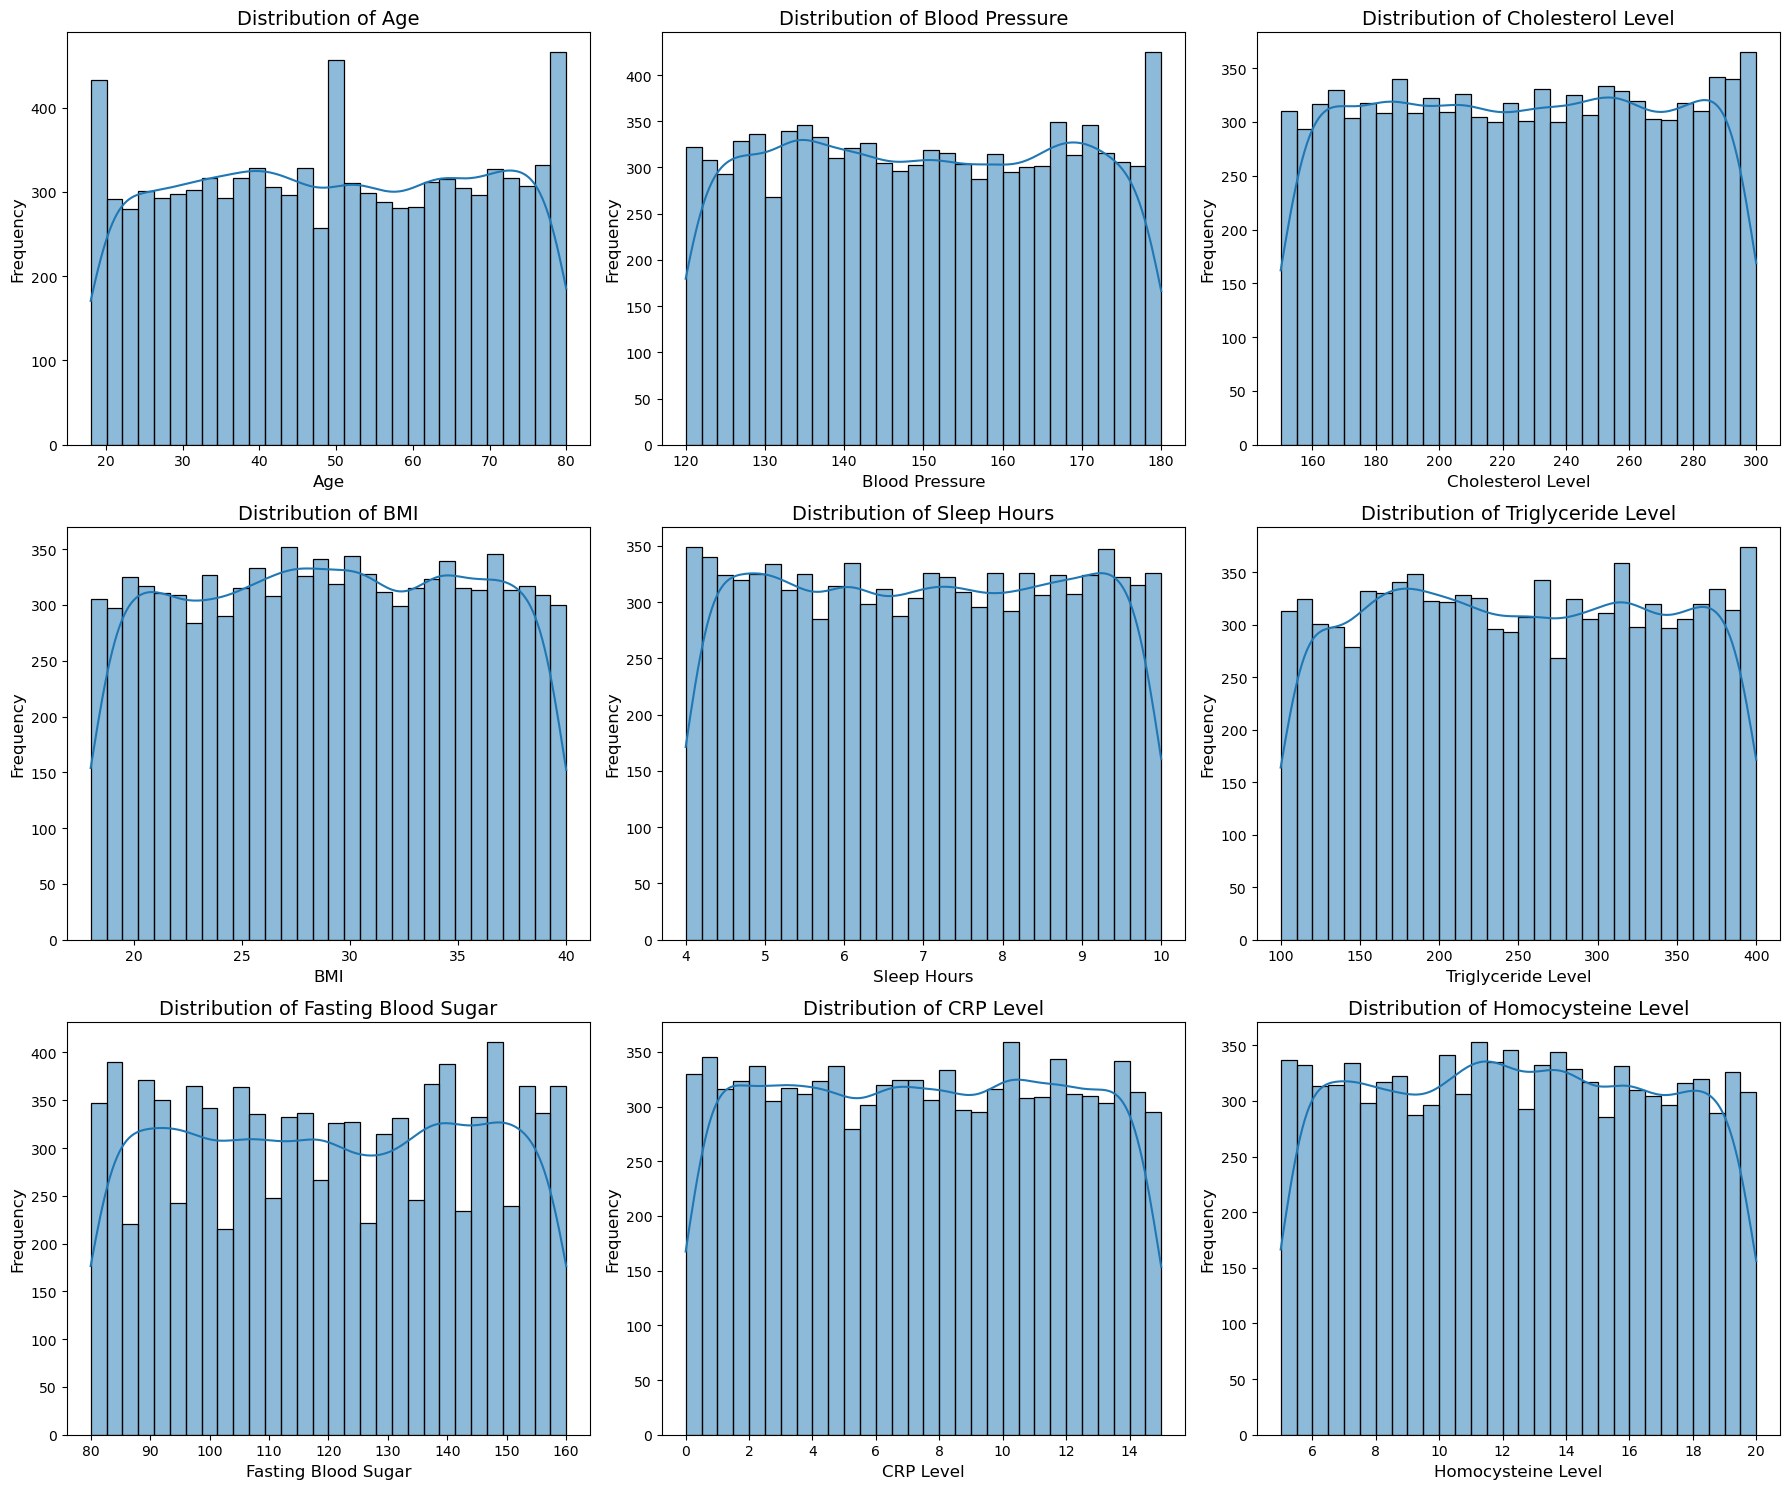


Distributions of Categorical Features



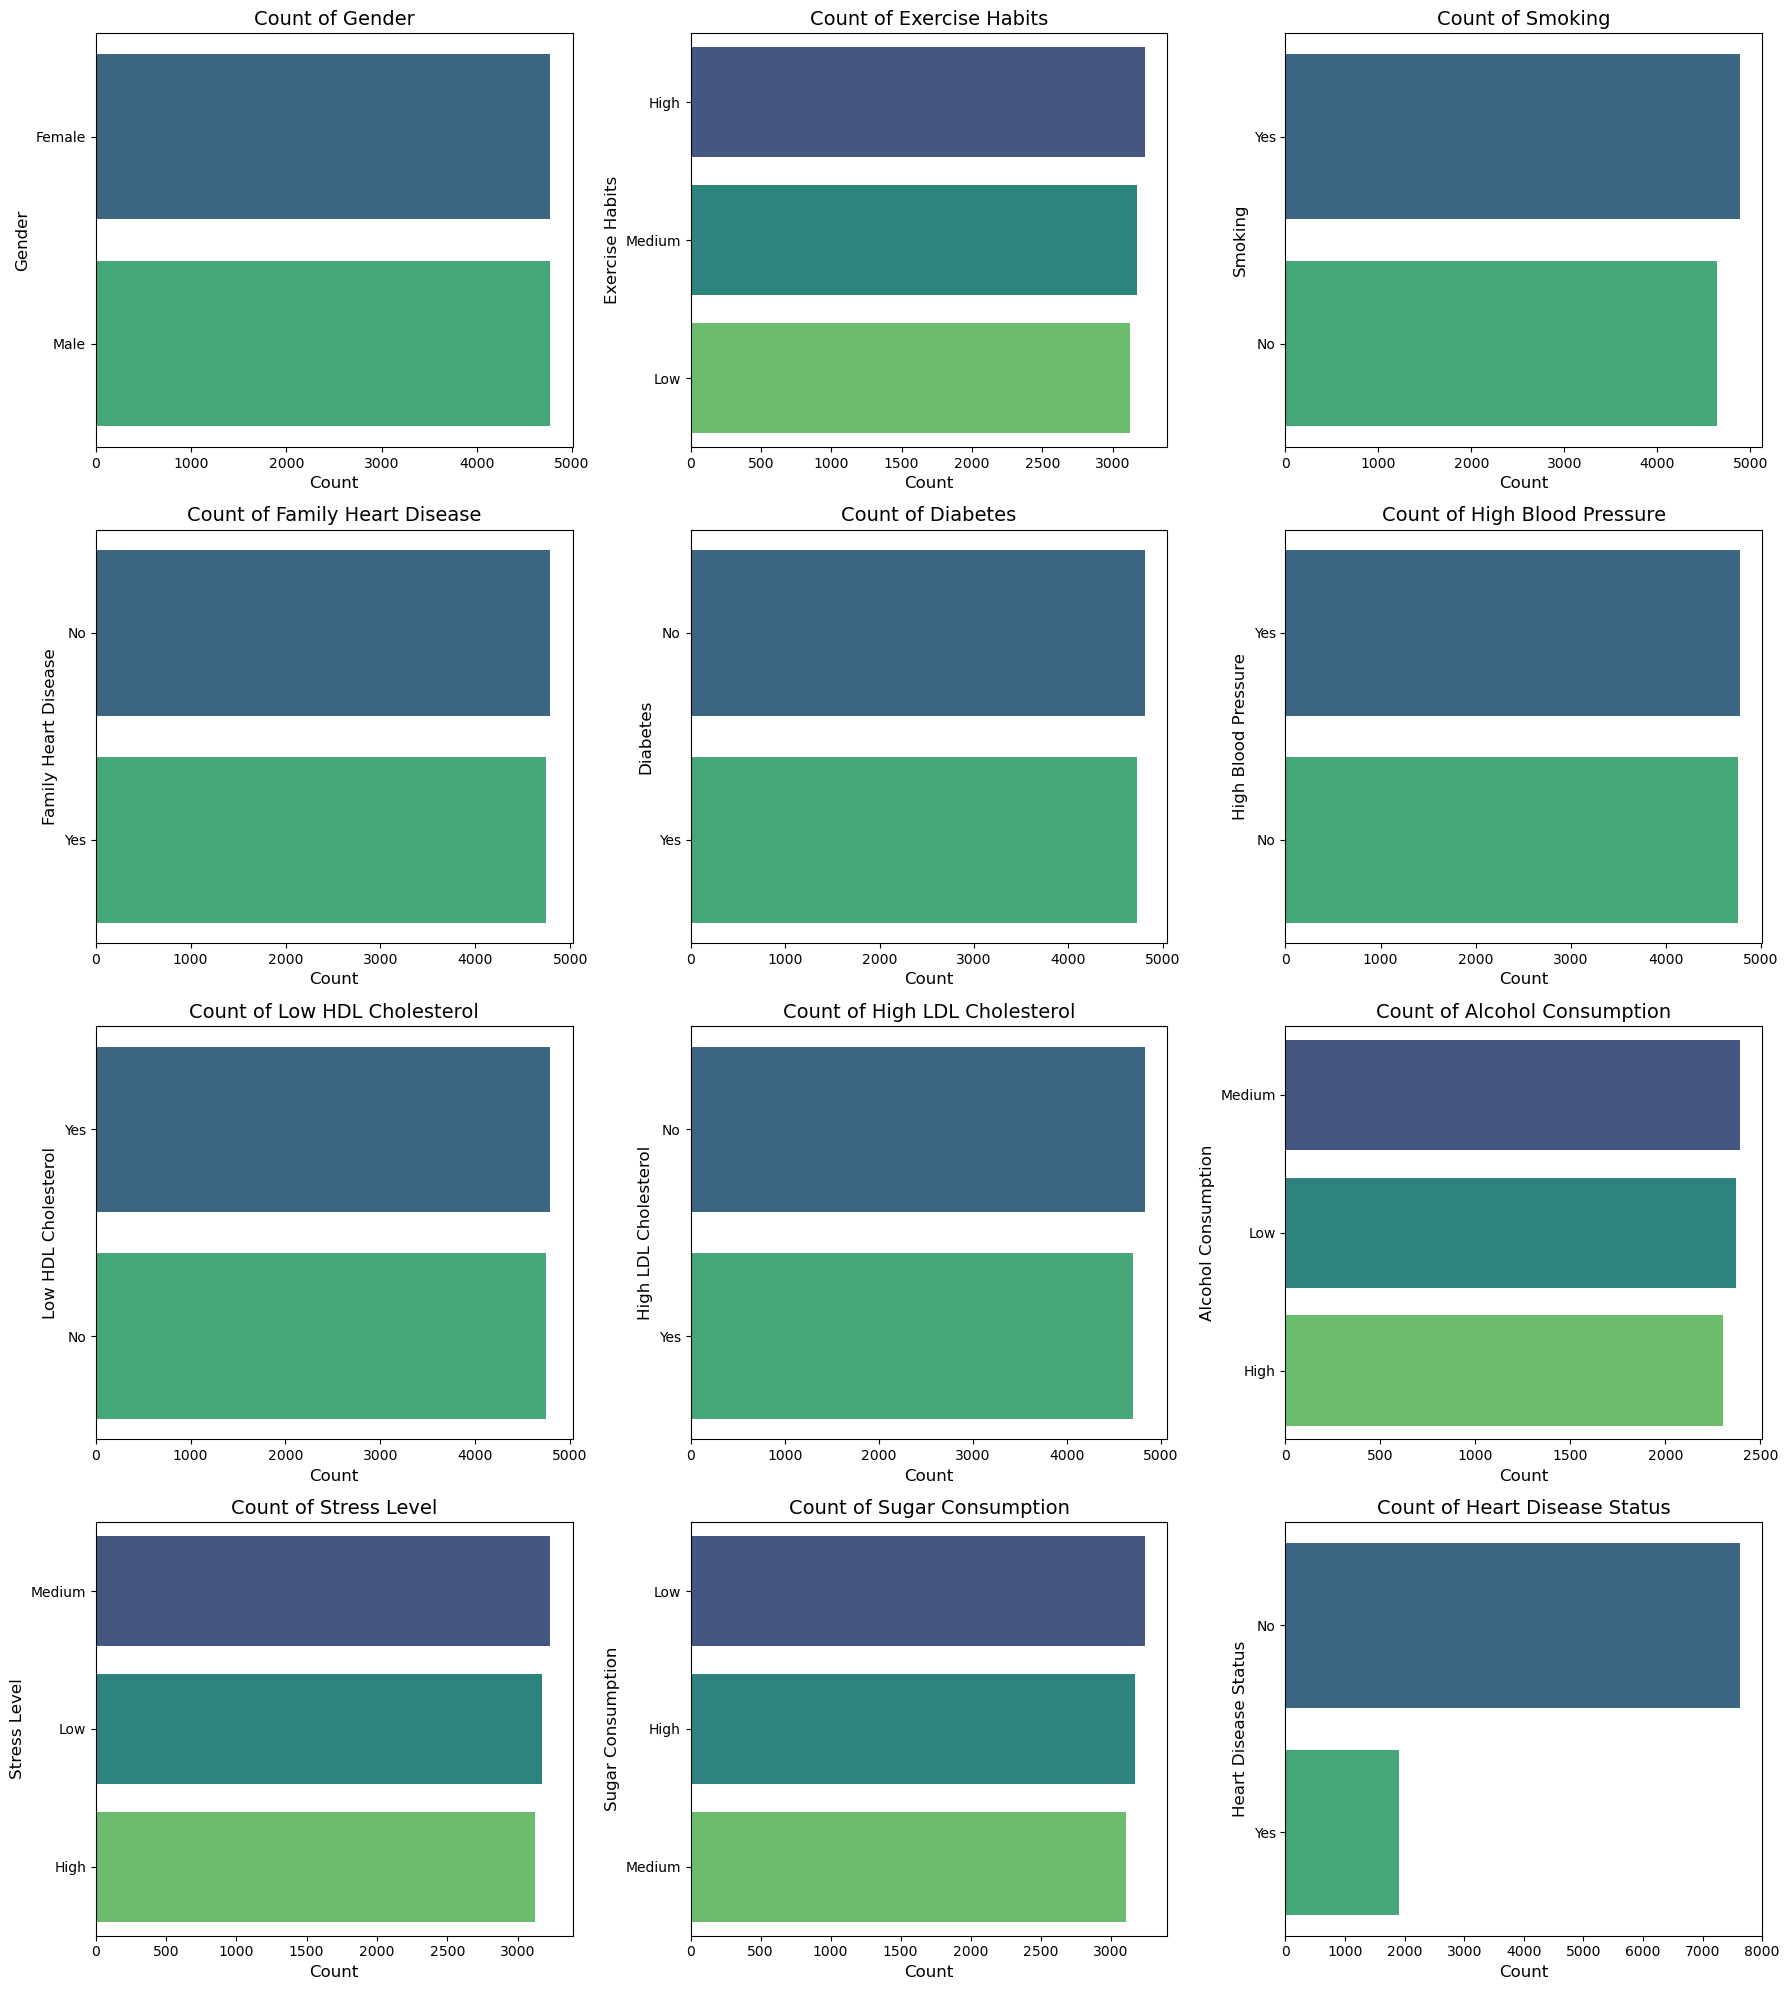

In [38]:
# Define numerical and categorical columns from df1
numerical_cols = ['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours', 'Triglyceride Level',
                    'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level']
categorical_cols = ['Gender', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes',
                     'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol',
                     'Alcohol Consumption', 'Stress Level', 'Sugar Consumption', 'Heart Disease Status']

print("\nDistributions of Numerical Features\n")
num_rows_num = (len(numerical_cols) + 2) // 3
plt.figure(figsize=(18, num_rows_num * 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows_num, 3, i + 1)
    sns.histplot(df_no_nan_except_Alc[col].dropna(), kde=True, bins=30)
    plt.title(f'Distribution of {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

print("\nDistributions of Categorical Features\n")
num_rows_cat = (len(categorical_cols) + 2) // 3
plt.figure(figsize=(18, num_rows_cat * 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(num_rows_cat, 3, i + 1)
    sns.countplot(y=col, data=df_no_nan_except_Alc.dropna(subset=[col]), palette='viridis', order=df_no_nan_except_Alc[col].value_counts().index)
    plt.title(f'Count of {col}', fontsize=14)
    plt.ylabel(col, fontsize=12)
    plt.xlabel('Count', fontsize=12)
plt.tight_layout()
plt.show()


## Categorical variables

In [40]:
categorical = ['Gender','Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes',
              'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol',
       'Alcohol Consumption', 'Stress Level', 'Sugar Consumption', 'Heart Disease Status']

## Numercial Variables

In [43]:
numerical = ['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours', 'Triglyceride Level',
             'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level']

## Check Missing Values

In [56]:
df_no_nan_except_Alc.isnull().sum()

Age                        0
Gender                     0
Blood Pressure             0
Cholesterol Level          0
Exercise Habits            0
Smoking                    0
Family Heart Disease       0
Diabetes                   0
BMI                        0
High Blood Pressure        0
Low HDL Cholesterol        0
High LDL Cholesterol       0
Alcohol Consumption     2465
Stress Level               0
Sleep Hours                0
Sugar Consumption          0
Triglyceride Level         0
Fasting Blood Sugar        0
CRP Level                  0
Homocysteine Level         0
Heart Disease Status       0
dtype: int64

## fill Alcohol Consumption with unknown

In [66]:
df_no_nan_except_Alc['Alcohol Consumption'] = df_no_nan_except_Alc['Alcohol Consumption'].fillna('Unknown')
df_no_nan = df_no_nan_except_Alc.copy()
df_no_nan.isnull().sum()

Age                     0
Gender                  0
Blood Pressure          0
Cholesterol Level       0
Exercise Habits         0
Smoking                 0
Family Heart Disease    0
Diabetes                0
BMI                     0
High Blood Pressure     0
Low HDL Cholesterol     0
High LDL Cholesterol    0
Alcohol Consumption     0
Stress Level            0
Sleep Hours             0
Sugar Consumption       0
Triglyceride Level      0
Fasting Blood Sugar     0
CRP Level               0
Homocysteine Level      0
Heart Disease Status    0
dtype: int64

## Unique Variables for Categorical data

In [71]:
df_categorical = df_no_nan[['Gender','Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes',
              'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol',
       'Alcohol Consumption', 'Stress Level', 'Sugar Consumption', 'Heart Disease Status']]

unique_values = df_categorical.apply(pd.Series.unique)
unique_values

Gender                                [Female, Male]
Exercise Habits                  [High, Low, Medium]
Smoking                                    [No, Yes]
Family Heart Disease                       [Yes, No]
Diabetes                                   [Yes, No]
High Blood Pressure                        [No, Yes]
Low HDL Cholesterol                        [Yes, No]
High LDL Cholesterol                       [No, Yes]
Alcohol Consumption     [Medium, Low, Unknown, High]
Stress Level                     [High, Low, Medium]
Sugar Consumption                [Medium, Low, High]
Heart Disease Status                       [No, Yes]
dtype: object

## Categorical Features Encoding

In [74]:
# Skewness measures the asymmetry of a distribution.
# It tells  if the data is balanced around the mean or leaning to one side.
# -0.5 to 0.5 Approximately symmetric → usually fine, no transformation needed
pd.DataFrame({"skewness" : df[numerical].skew(axis = 0, skipna = True) })


,skewness
Age,-0.006789
Blood Pressure,0.013907
Cholesterol Level,-0.007120
BMI,-0.021342
Sleep Hours,0.000172
Triglyceride Level,0.006142
Fasting Blood Sugar,-0.008915
CRP Level,-0.004069
Homocysteine Level,0.007886


## Convert categorical variables to numerical

In [98]:
df_num = df_no_nan.copy()

In [100]:
df_num['Gender'].replace(["Male", "Female"], [0,1], inplace = True)
df_num['Exercise Habits'].replace(["High", "Medium", "Low"], [0,1,2], inplace = True)
df_num['Smoking'].replace(["Yes", "No"], [1,0], inplace = True)
df_num['Family Heart Disease'].replace(["Yes", "No"], [1,0], inplace = True)
df_num['Diabetes'].replace(["Yes", "No"], [1,0], inplace = True)
df_num['High Blood Pressure'].replace(["Yes", "No"], [1,0], inplace = True)
df_num['Low HDL Cholesterol'].replace(["Yes", "No"], [1,0], inplace = True)
df_num['High LDL Cholesterol'].replace(["Yes", "No"], [1,0], inplace = True)
#df_num['Alcohol Consumption'].replace(["High", "Medium", "Low"], [0,1,2], inplace = True)
df_num['Stress Level'].replace(["High", "Medium", "Low"], [0,1,2], inplace = True)
df_num['Sugar Consumption'].replace(["High", "Medium", "Low"], [0,1,2], inplace = True)
df_num['Heart Disease Status'].replace(["Yes", "No"], [1,0], inplace = True)

In [102]:
df_num = pd.get_dummies(df_num, columns=['Alcohol Consumption'], drop_first=True)
df_num = df_num.astype(int)

In [104]:
df_num

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status,Alcohol Consumption_Low,Alcohol Consumption_Medium,Alcohol Consumption_Unknown
0,69,1,146,286,0,0,1,1,25,0,...,8,1,133,157,9,19,0,0,1,0
1,46,0,126,216,2,0,0,0,29,0,...,4,2,393,92,12,11,0,1,0,0
2,32,1,122,293,0,1,1,0,24,1,...,5,0,293,94,12,5,0,1,0,0
3,60,0,166,242,2,1,1,1,20,1,...,7,0,263,154,10,8,0,1,0,0
4,25,0,152,257,2,1,0,0,28,0,...,5,2,126,91,4,10,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9527,25,1,136,243,1,1,0,0,18,1,...,6,1,343,133,3,19,1,0,1,0
9528,38,0,172,154,1,0,0,0,31,1,...,8,2,377,83,2,9,1,0,0,1
9529,73,0,152,201,0,1,0,1,26,0,...,4,2,248,88,4,9,1,0,0,1
9530,23,0,142,299,2,1,0,1,34,1,...,8,1,113,153,7,11,1,0,1,0


In [108]:
df_num.isnull().sum()

Age                            0
Gender                         0
Blood Pressure                 0
Cholesterol Level              0
Exercise Habits                0
Smoking                        0
Family Heart Disease           0
Diabetes                       0
BMI                            0
High Blood Pressure            0
Low HDL Cholesterol            0
High LDL Cholesterol           0
Stress Level                   0
Sleep Hours                    0
Sugar Consumption              0
Triglyceride Level             0
Fasting Blood Sugar            0
CRP Level                      0
Homocysteine Level             0
Heart Disease Status           0
Alcohol Consumption_Low        0
Alcohol Consumption_Medium     0
Alcohol Consumption_Unknown    0
dtype: int64

In [ ]:
known_data = df5[df5["Alcohol Consumption"].notna()]
unknown_data = df5[df5["Alcohol Consumption"].isna()]

In [ ]:
X_train = known_data.drop('Alcohol Consumption', axis=1)
y_train = known_data['Alcohol Consumption']

X_test = unknown_data.drop('Alcohol Consumption', axis=1)
y_test = unknown_data['Alcohol Consumption']

In [ ]:
# Calculate the mode of 'Alcohol Consumption' from the known data
mode_alcohol_consumption = known_data['Alcohol Consumption'].mode()[0]

# Fill in the missing values in df5 with the calculated mode
df5['Alcohol Consumption'] = df5['Alcohol Consumption'].fillna(mode_alcohol_consumption).astype(int)


In [ ]:
df5

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,69.0,1,146.0,286.0,0,1,0,0,25.221799,1,...,1,1,0,8.744034,1,133.0,157.0,9.355389,19.298875,1
1,46.0,0,126.0,216.0,2,1,1,1,29.855447,1,...,0,2,2,4.440440,2,393.0,92.0,12.709873,11.230926,1
2,32.0,1,122.0,293.0,0,0,0,1,24.130477,0,...,0,2,0,5.249405,0,293.0,94.0,12.509046,5.961958,1
3,60.0,0,166.0,242.0,2,0,0,0,20.486289,0,...,1,2,0,7.030971,0,263.0,154.0,10.381259,8.153887,1
4,25.0,0,152.0,257.0,2,0,1,1,28.144681,1,...,1,2,1,5.504876,2,126.0,91.0,4.297575,10.815983,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9527,25.0,1,136.0,243.0,1,0,1,1,18.788791,0,...,0,1,0,6.834954,1,343.0,133.0,3.588814,19.132004,0
9528,38.0,0,172.0,154.0,1,1,1,1,31.856801,0,...,0,1,0,8.247784,2,377.0,83.0,2.658267,9.715709,0
9529,73.0,0,152.0,201.0,0,0,1,0,26.899911,1,...,0,1,2,4.436762,2,248.0,88.0,4.408867,9.492429,0
9530,23.0,0,142.0,299.0,2,0,1,0,34.964026,0,...,0,1,0,8.526329,1,113.0,153.0,7.215634,11.873486,0


In [ ]:
df5.isnull().sum()

,0
Age,0
Gender,0
Blood Pressure,0
Cholesterol Level,0
Exercise Habits,0
Smoking,0
Family Heart Disease,0
Diabetes,0
BMI,0
High Blood Pressure,0


# 9. Apply SMOTE to the train dataset to balance target values

In [185]:
# The target values are imbalanced, so we apply the SMOTE method to address this imbalance.
value_counts = df_num['Heart Disease Status'].value_counts()
value_counts

Heart Disease Status
0    7621
1    1911
Name: count, dtype: int64

In [187]:
X = df_num.drop("Heart Disease Status", axis = 1)

In [189]:
y = df_num["Heart Disease Status"].astype(int) # Ensure y is a 1D pandas Series and explicitly cast to int

In [191]:
print("X shape is", X.shape)
print("y shape is", y.shape)

X shape is (9532, 22)
y shape is (9532,)


In [193]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [195]:
smote = SMOTE(sampling_strategy='auto', random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


In [197]:
y_train_res.value_counts()

Heart Disease Status
1    6093
0    6093
Name: count, dtype: int64

In [199]:
X_train_res.shape

(12186, 22)

In [201]:
y_train_res.shape

(12186,)

In [214]:
y_test.shape

(1907,)

# Normalize Data

In [204]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)


In [206]:
X_train_scaled

array([[ 0.2210827 , -0.85209291, -1.58664613, ..., -0.47197179,
        -0.46506887, -0.47534801],
       [ 0.72801386, -0.85209291,  0.85728494, ..., -0.47197179,
         2.15021919, -0.47534801],
       [-0.79277962,  1.17358095,  1.38098446, ..., -0.47197179,
        -0.46506887,  2.10372184],
       ...,
       [-0.45482551,  1.17358095, -0.01554758, ..., -0.47197179,
        -0.46506887, -0.47534801],
       [ 0.61536249,  1.17358095, -1.17932428, ..., -0.47197179,
        -0.46506887, -0.47534801],
       [ 0.84066523, -0.85209291,  0.85728494, ..., -0.47197179,
        -0.46506887, -0.47534801]])

In [208]:
X_train_norm = pd.DataFrame(X_train_scaled, columns=X_train_res.columns)
X_test_norm = pd.DataFrame(X_test_scaled, columns=X_test.columns)
X_train_norm

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Alcohol Consumption_Low,Alcohol Consumption_Medium,Alcohol Consumption_Unknown
0,0.221083,-0.852093,-1.586646,0.024993,-1.089756,-0.854965,-0.812538,1.215870,-0.598115,-0.822877,...,0.148726,-0.804732,0.169685,-0.752509,-0.159689,1.285832,1.040050,-0.471972,-0.465069,-0.475348
1,0.728014,-0.852093,0.857285,1.520092,0.192198,-0.854965,-0.812538,1.215870,-0.598115,-0.822877,...,0.148726,-0.804732,1.447674,-0.775434,-1.071479,1.532960,-0.446177,-0.471972,2.150219,-0.475348
2,-0.792780,1.173581,1.380984,-1.516109,0.192198,1.169638,-0.812538,-0.822456,1.761375,-0.822877,...,-1.154207,-0.188555,0.169685,-1.119307,0.882355,1.285832,-0.693881,-0.471972,-0.465069,2.103722
3,-0.623803,-0.852093,-1.412080,-0.504042,1.474153,1.169638,-0.812538,1.215870,1.424305,1.215249,...,0.148726,-0.188555,-1.108304,-1.245394,1.186285,1.780087,1.535458,-0.471972,-0.465069,-0.475348
4,0.446385,1.173581,1.148229,-1.585114,1.474153,1.169638,-0.812538,-0.822456,-1.272255,1.215249,...,1.451660,-1.420909,-1.108304,-1.658042,1.142867,-1.432575,-0.446177,-0.471972,-0.465069,-0.475348
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12181,0.559037,-0.852093,0.391774,-0.596048,-1.089756,-0.854965,-0.812538,-0.822456,0.244560,-0.822877,...,0.148726,-0.804732,1.447674,0.393736,1.316541,-0.938319,0.049232,-0.471972,2.150219,-0.475348
12182,0.615362,-0.852093,0.566341,-1.033077,0.192198,-0.854965,-0.812538,-0.822456,1.424305,1.215249,...,0.148726,-0.804732,1.447674,-0.064762,0.231077,-0.691192,1.287754,-0.471972,-0.465069,-0.475348
12183,-0.454826,1.173581,-0.015548,1.589097,1.474153,-0.854965,-0.812538,-0.822456,-0.766650,-0.822877,...,-1.154207,0.427623,0.169685,-1.680967,-0.376782,-0.691192,-1.189290,-0.471972,-0.465069,-0.475348
12184,0.615362,1.173581,-1.179324,-0.987074,-1.089756,-0.854965,-0.812538,-0.822456,1.087235,-0.822877,...,-1.154207,-0.804732,0.169685,-0.454485,-0.767549,0.791576,1.535458,-0.471972,-0.465069,-0.475348


In [210]:
X_train, X_test, y_train, y_test = X_train_norm, X_test_norm, y_train_res,y_test

In [212]:
print(X_train.shape , X_test.shape, y_train.shape, y_test.shape)

(12186, 22) (1907, 22) (12186,) (1907,)


# ML Models

## XGBClassifier

In [154]:
# Initialize and train XGBoost model
xgb_model =  (n_estimators=50, learning_rate=0.1, max_depth=3, random_state=42)
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluation
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.80      0.80      1528
           1       0.22      0.22      0.22       379

    accuracy                           0.69      1907
   macro avg       0.51      0.51      0.51      1907
weighted avg       0.69      0.69      0.69      1907



In [156]:
print("XGB Model Accuracy Score:", round(accuracy_score(y_test, y_pred_xgb) * 100, 2), "%")

XGB Model Accuracy Score: 68.75 %


In [158]:
print("XGB Cross-validation score:", cross_val_score(xgb_model , y_test, y_pred_xgb, cv = 10).mean())

XGB Cross-validation score: 0.7970680628272251


In [160]:
print("\nXGB Confusion Matrix:\n", confusion_matrix(y_test,y_pred_xgb))


XGB Confusion Matrix:
 [[1226  302]
 [ 294   85]]


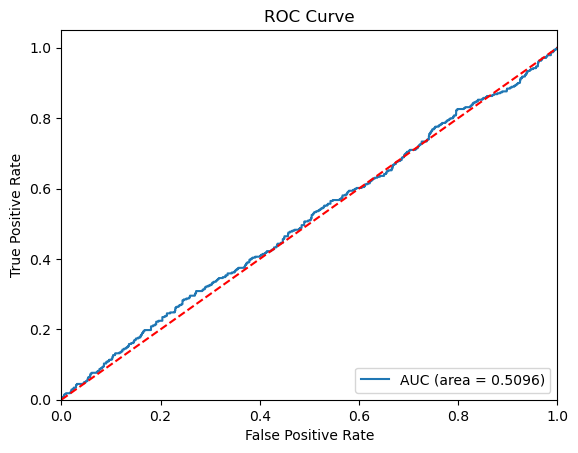

In [162]:
Xgb_roc_auc = roc_auc_score(y_test, y_prob_xgb)

fpr, tpr, thresholds = roc_curve(y_test, xgb_model.predict_proba(X_test)[:,1])

plt.figure()
plt.plot(fpr, tpr, label = "AUC (area = %0.4f)" % Xgb_roc_auc)
plt.plot([0,1], [0,1], "r--")
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

In [216]:
X_train_aucpr, X_val, y_train_aucpr, y_val = train_test_split(
    X_train, 
    y_train,
    test_size=0.15,           
    stratify=y_train,  
    random_state=42
)

In [224]:
model = XGBClassifier(
    scale_pos_weight=1,           
    eval_metric='aucpr',           
    early_stopping_rounds=50,      
    random_state=42,
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist'
)

 
model.fit(
    X_train_aucpr, y_train_aucpr,           
    eval_set=[(X_val, y_val)],  
    verbose=False
)

print("Finished！The best iteration number is:", model.best_iteration)

Finished！The best iteration number is: 999


In [228]:
from sklearn.metrics import precision_recall_curve
val_proba = model.predict_proba(X_val)[:, 1]
prec, rec, thresh = precision_recall_curve(y_val, val_proba)

f2 = (5 * prec * rec) / (4 * prec + rec + 1e-8)
best_thresh = thresh[np.argmax(f2)]

print("Best threashold in validate dataset is:", round(best_thresh, 4))

Best threashold in validate dataset is: 0.1432


In [237]:
test_proba = model.predict_proba(X_test)[:, 1]
y_pred = (test_proba >= best_thresh).astype(int)


print(classification_report(y_test, y_pred))
print("refusion matrix:\n", confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.57      0.67      1528
           1       0.22      0.47      0.30       379

    accuracy                           0.55      1907
   macro avg       0.52      0.52      0.48      1907
weighted avg       0.70      0.55      0.60      1907

refusion matrix:
 [[874 654]
 [199 180]]


## MLP

In [241]:
mlp_model = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=300, activation='relu', solver='adam', random_state=42)

# Train the MLP model
mlp_model.fit(X_train, y_train)

y_pred_mlp = mlp_model.predict(X_test)
y_prob_mlp = mlp_model.predict_proba(X_test)[:, 1]


print("MLP Classification Report:")
print(classification_report(y_test, y_pred_mlp))



MLP Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.75      0.77      1528
           1       0.21      0.26      0.23       379

    accuracy                           0.65      1907
   macro avg       0.50      0.51      0.50      1907
weighted avg       0.69      0.65      0.67      1907



In [176]:
print("MLP Model Accuracy Score:", round(accuracy_score(y_test, y_pred_mlp) * 100, 2), "%")

MLP Model Accuracy Score: 69.53 %


In [178]:
print("\nMLP Cross-validation score:", cross_val_score(mlp_model, X_train, y_train, cv=5).mean())


MLP Cross-validation score: 0.793555902424443


In [180]:
print("\nMLP Confusion Matrix:\n", confusion_matrix(y_test, y_pred_mlp))


MLP Confusion Matrix:
 [[1255  273]
 [ 308   71]]


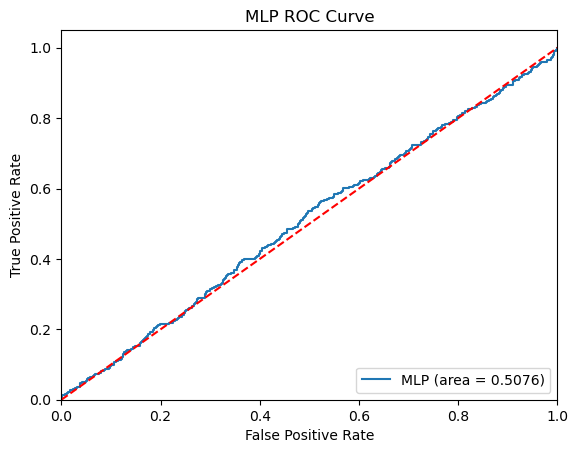

In [182]:
# ROC Curve and AUC Score
mlp_roc_auc = roc_auc_score(y_test, mlp_model.predict_proba(X_test)[:,1])
fpr, tpr, thresholds = roc_curve(y_test, mlp_model.predict_proba(X_test)[:,1])

plt.figure()
plt.plot(fpr, tpr, label='MLP (area = %0.4f)' % mlp_roc_auc)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('MLP ROC Curve')
plt.legend(loc="lower right")
plt.show()

## LightGBM

In [243]:
# Initialize and train LightGBM model
lgb_model = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=-1, random_state=42)
lgb_model.fit(X_train, y_train)

# Predictions
y_pred_lgb3 = lgb_model.predict(X_test)
y_prob_lgb3 = lgb_model.predict_proba(X_test)[:, 1]

print("LightGBM Classification Report:")
print(classification_report(y_test, y_pred_lgb3))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 6093, number of negative: 6093
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001128 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 709
[LightGBM] [Info] Number of data points in the train set: 12186, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LightGBM Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.87      0.83      1528
           1       0.22      0.15      0.18       379

    accuracy                           0.72      1907
   macro avg       0.51      0.51      0.50      1907
weighted avg       0.69      0.72      0.70      1907



In [245]:
print("MLP Model Accuracy Score:", round(accuracy_score(y_test, y_pred_lgb3) * 100, 2), "%")

MLP Model Accuracy Score: 72.36 %


In [247]:
print("\nMLP Cross-validation score:", cross_val_score(mlp_model, X_train, y_train, cv=5).mean())


MLP Cross-validation score: 0.743410667441343


In [248]:
print("\nXGB Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lgb3))


XGB Confusion Matrix:
 [[1324  204]
 [ 323   56]]


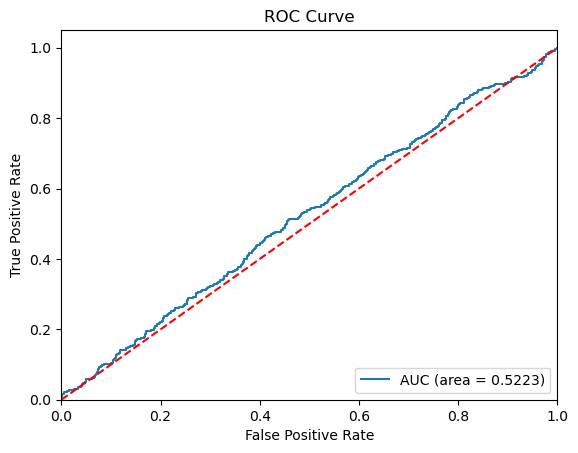

In [249]:
lgb_roc_auc = roc_auc_score(y_test, y_prob_lgb3)

fpr, tpr, thresholds = roc_curve(y_test, lgb_model.predict_proba(X_test)[:,1])

plt.figure()
plt.plot(fpr, tpr, label = "AUC (area = %0.4f)" % lgb_roc_auc)
plt.plot([0,1], [0,1], "r--")
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

In [259]:
y_train_cnn_cat = to_categorical(y_train)
y_test_cnn_cat = to_categorical(y_test)
X_train_cnn = X_train.values[..., np.newaxis]
X_test_cnn = X_test.values[..., np.newaxis]


In [271]:
def create_cnn_model(input_shape):
    model = Sequential()
    model.add(Conv1D(filters=32, kernel_size=2, activation='relu', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))
    model.add(Conv1D(filters=64, kernel_size=2, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))
    model.add(Flatten())
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(2, activation='softmax'))
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [273]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for train_idx, val_idx in kfold.split(X_train_cnn, y_train):
    X_tr, X_val = X_train_cnn[train_idx], X_train_cnn[val_idx]
    y_tr, y_val = y_train_cnn_cat[train_idx], y_train_cnn_cat[val_idx]

    model = create_cnn_model(input_shape=(X_tr.shape[1], 1))
    model.fit(X_tr, y_tr, epochs=20, batch_size=32, verbose=0)

    val_pred = np.argmax(model.predict(X_val), axis=1)
    val_true = np.argmax(y_val, axis=1)
    acc = accuracy_score(val_true, val_pred)
    cv_scores.append(acc)


print(f"\nCNN Mean CV Accuracy: {np.mean(cv_scores) * 100:.4f} %")
print(f"\nCNN Cross-validation scores: {cv_scores}")

2026-03-17 22:23:39.306958: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


77/77 [==============================] - 0s 452us/step

CNN Mean CV Accuracy: 78.9841 %

CNN Cross-validation scores: [0.7883511074651354, 0.8005744768157571, 0.7792367665162084, 0.794009027492819, 0.7870332375871973]


In [274]:
cnn_model = create_cnn_model(input_shape=(X_train_cnn.shape[1], 1))
cnn_model.fit(X_train_cnn, y_train_cnn_cat, epochs=20, batch_size=32, verbose=0)

y_pred_prob_cnn = cnn_model.predict(X_test_cnn)

y_pred_cnn = np.argmax(y_pred_prob_cnn, axis=1)
y_prob_cnn = y_pred_prob_cnn[:, 1]

print("CNN Classification Report:\n", classification_report(y_test, y_pred_cnn))
print("CNN Accuracy Score:", accuracy_score(y_test, y_pred_cnn))
print("CNN Confusion Matrix:\n", confusion_matrix(y_test, y_pred_cnn))


60/60 [==============================] - 0s 497us/step
CNN Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.86      0.83      1528
           1       0.21      0.15      0.17       379

    accuracy                           0.72      1907
   macro avg       0.50      0.50      0.50      1907
weighted avg       0.68      0.72      0.70      1907

CNN Accuracy Score: 0.7152595700052439
CNN Confusion Matrix:
 [[1307  221]
 [ 322   57]]


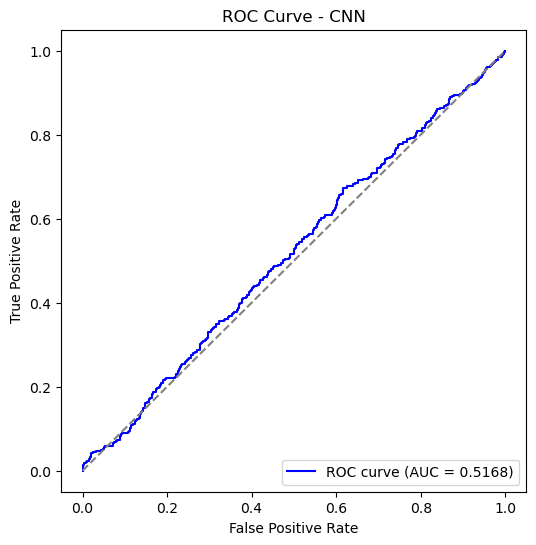

In [275]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_cnn)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - CNN')
plt.legend(loc='lower right')
plt.show()

## TabTransformer


In [279]:
class TabTransformer(nn.Module):
    def __init__(self, num_features, dim=64, depth=2, heads=4, mlp_dim=128,
                 dropout=0.2, num_classes=2):
        super().__init__()
        self.num_features = num_features
        self.feature_norm = nn.LayerNorm(num_features)
        self.embedding = nn.Linear(1, dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim,
            nhead=heads,
            dim_feedforward=mlp_dim,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.feature_gate_net = nn.Sequential(
            nn.Linear(num_features, 64),
            nn.ReLU(),
            nn.Linear(64, num_features),
            nn.Sigmoid()
        )

        self.mlp = nn.Sequential(
            nn.LayerNorm(dim * num_features),
            nn.Linear(dim * num_features, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, mlp_dim//2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim//2, num_classes)
        )

    def forward(self, x):
        x_original = x

        gate = self.feature_gate_net(self.feature_norm(x_original))
        gate = gate.unsqueeze(-1)

        x = x.unsqueeze(-1)
        x = self.embedding(x)
        x = x * gate
        x = self.transformer(x)
        x = x.flatten(start_dim=1)

        return self.mlp(x)

In [281]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
X_test_tensor  = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test.values, dtype=torch.long)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
MAX_EPOCHS = 200
BATCH_SIZE = 128
cv_scores = []
test_preds_folds_tf = []

In [ ]:
for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_tensor, y_train_tensor)):
    print(f"\nFOLD {fold+1}")

    train_dataset = TensorDataset(X_train_tensor[train_idx], y_train_tensor[train_idx])
    val_dataset   = TensorDataset(X_train_tensor[val_idx], y_train_tensor[val_idx])

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Create model
    model = TabTransformer(num_features=X_train_tensor.shape[1]).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, T_mult=2
    )
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

    best_val_loss = float("inf")
    patience = 15
    patience_count = 0

    # ------------------ Training ------------------
    for epoch in range(MAX_EPOCHS):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            scheduler.step()

        # ------------------ Validation ------------------
        model.eval()
        val_losses = []
        y_true_fold, y_pred_fold = [], []

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)

                logits = model(X_batch)
                loss = criterion(logits, y_batch)
                val_losses.append(loss.item())

                preds = torch.argmax(logits, dim=1)
                y_true_fold.extend(y_batch.cpu().numpy())
                y_pred_fold.extend(preds.cpu().numpy())

        val_loss = np.mean(val_losses)
        val_acc = accuracy_score(y_true_fold, y_pred_fold)

        print(f"Epoch {epoch+1} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()
            patience_count = 0
        else:
            patience_count += 1

        if patience_count >= patience:
            print("Early stopping triggered!")
            break

    model.load_state_dict(best_model_state)

    cv_scores.append(val_acc)

    test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor),
                             batch_size=BATCH_SIZE, shuffle=False)

    test_probs = []
    model.eval()
    with torch.no_grad():
        for X_batch, _ in test_loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            probs = F.softmax(logits, dim=1)
            test_probs.extend(probs.cpu().numpy())

    test_preds_folds_tf.append(np.array(test_probs))


FOLD 1
Epoch 1 | Val Loss: 0.5027 | Val Acc: 0.7781
Epoch 2 | Val Loss: 0.5342 | Val Acc: 0.7469
Epoch 3 | Val Loss: 0.4942 | Val Acc: 0.7806
Epoch 4 | Val Loss: 0.4899 | Val Acc: 0.7855
Epoch 5 | Val Loss: 0.4968 | Val Acc: 0.7691
Epoch 6 | Val Loss: 0.4899 | Val Acc: 0.7838
Epoch 7 | Val Loss: 0.4897 | Val Acc: 0.7863
Epoch 8 | Val Loss: 0.4905 | Val Acc: 0.7851
Epoch 9 | Val Loss: 0.4997 | Val Acc: 0.7699
Epoch 10 | Val Loss: 0.5111 | Val Acc: 0.7678
Epoch 11 | Val Loss: 0.4971 | Val Acc: 0.7842
Epoch 12 | Val Loss: 0.4920 | Val Acc: 0.7777
Epoch 13 | Val Loss: 0.4916 | Val Acc: 0.7851
Epoch 14 | Val Loss: 0.4979 | Val Acc: 0.7760
Epoch 15 | Val Loss: 0.4976 | Val Acc: 0.7818
Epoch 16 | Val Loss: 0.4990 | Val Acc: 0.7830
Epoch 17 | Val Loss: 0.5222 | Val Acc: 0.7752
Epoch 18 | Val Loss: 0.4974 | Val Acc: 0.7875
Epoch 19 | Val Loss: 0.5035 | Val Acc: 0.7834
Epoch 20 | Val Loss: 0.5125 | Val Acc: 0.7719
Epoch 21 | Val Loss: 0.5024 | Val Acc: 0.7847
Epoch 22 | Val Loss: 0.4958 | Val A

In [ ]:
print("\n========== CV RESULTS ==========")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")


final_test_probs_tf = np.mean(test_preds_folds_tf, axis=0)
final_test_preds_tf = np.argmax(final_test_probs_tf, axis=1)

y_true = y_test_tensor.numpy()
y_prob_pos_tf = final_test_probs_tf[:, 1]

print("\nFINAL TEST RESULTS")
print("Test Accuracy:", accuracy_score(y_true, final_test_preds_tf))
print("Classification Report:\n", classification_report(y_true, final_test_preds_tf))
print("Confusion Matrix:\n", confusion_matrix(y_true, final_test_preds_tf))

In [ ]:
fpr, tpr, thresholds = roc_curve(y_true, y_prob_pos_tf)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,7))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Enhanced TabTransformer v2")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


## SVC

In [ ]:
svc_model = SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42)
svc_model.fit(X_train, y_train)


y_pred_svc = svc_model.predict(X_test)
y_prob_svc = svc_model.predict_proba(X_test)[:, 1]


acc = accuracy_score(y_test, y_pred_svc)
f1 = f1_score(y_test, y_pred_svc, average='macro')
auc_scv = roc_auc_score(y_test, y_prob_svc)

print("SVC RESULTS")
print(f"Accuracy: {acc:.4f}")
print(f"F1-macro: {f1:.4f}")
print(f"ROC-AUC: {auc_scv:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_svc))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svc))

===== SVC RESULTS ===telek
Accuracy: 0.7668
F1-macro: 0.7666
ROC-AUC: 0.8319

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.73      0.76      1525
           1       0.75      0.80      0.77      1524

    accuracy                           0.77      3049
   macro avg       0.77      0.77      0.77      3049
weighted avg       0.77      0.77      0.77      3049

Confusion Matrix:
 [[1119  406]
 [ 305 1219]]


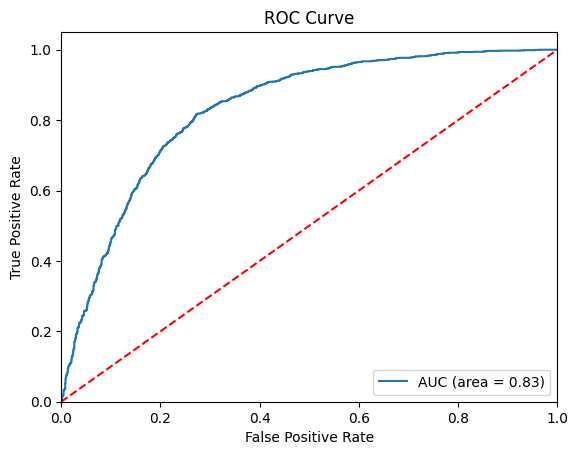

In [ ]:

fpr, tpr, thresholds = roc_curve(y_test, svc_model.predict_proba(X_test)[:,1])

plt.figure()
plt.plot(fpr, tpr, label = "AUC (area = %0.2f)" % auc_scv)
plt.plot([0,1], [0,1], "r--")
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

# Compare

In [ ]:
from sklearn.metrics import  f1_score



===== MODEL COMPARISON ====
            Model  Accuracy  F1-macro   ROC-AUC
0        LightGBM  0.804854  0.804660  0.870052
1  TabTransformer  0.777304  0.776847  0.840670
2             SVC  0.766809  0.766558  0.831853
3             CNN  0.755986  0.755937  0.825036
4         XGBoost  0.746802  0.746794  0.817507
5             MLP  0.723844  0.723490  0.802284


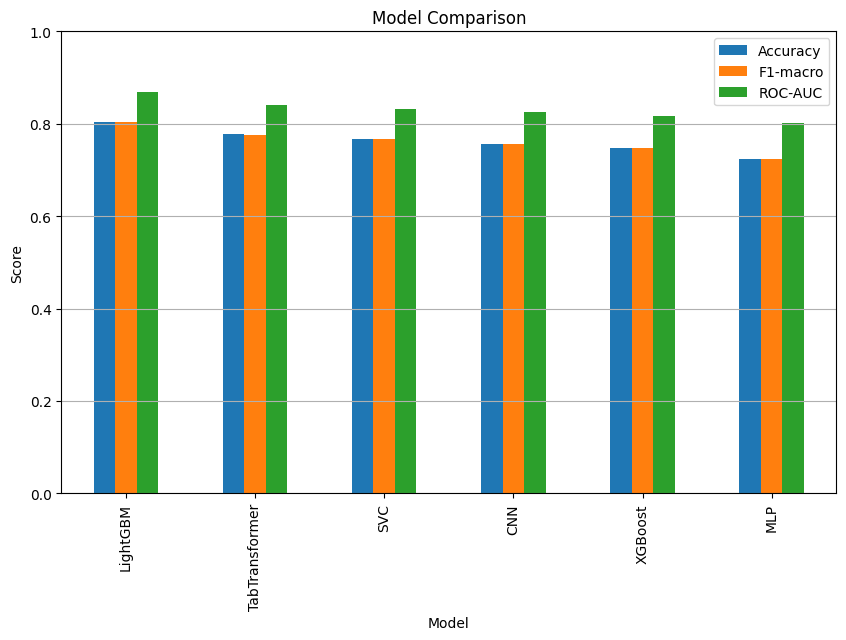

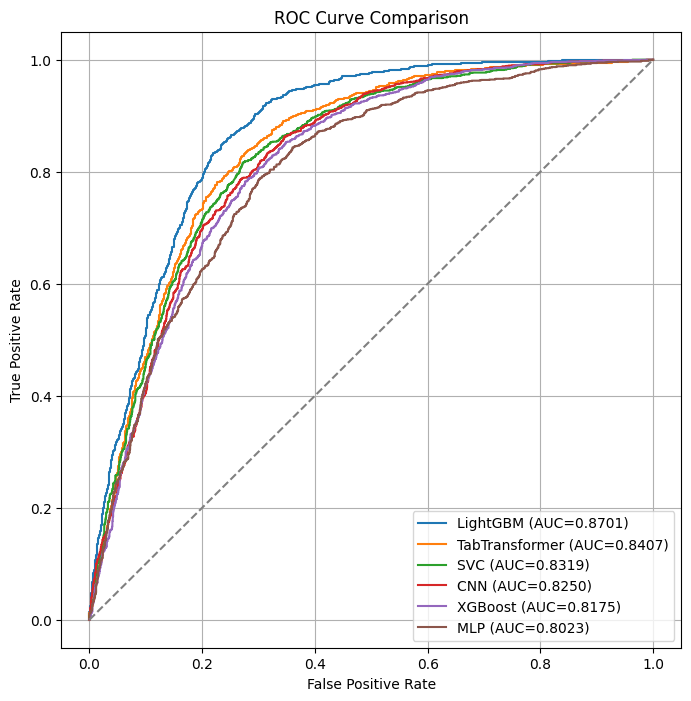

In [ ]:
models_results = {
    "MLP": {"pred": y_pred_mlp, "prob": y_prob_mlp},
    "CNN": {"pred": y_pred_cnn, "prob": y_prob_cnn},
    "XGBoost": {"pred": y_pred_xgb, "prob": y_prob_xgb},
    "LightGBM": {"pred": y_pred_lgb3, "prob": y_prob_lgb3},
    "TabTransformer": {"pred": final_test_preds_tf, "prob": y_prob_pos_tf},
    "SVC": {"pred": y_pred_svc, "prob": y_prob_svc},
}

results_summary = []
roc_data = []

for name, res in models_results.items():
    acc = accuracy_score(y_true, res["pred"])
    f1 = f1_score(y_true, res["pred"], average='macro')

    prob = res["prob"]
    if prob.ndim == 2 and prob.shape[1] == 2:
        prob = prob[:, 1]

    auc_score = roc_auc_score(y_true, prob)

    fpr, tpr, _ = roc_curve(y_true, prob)
    roc_data.append({'name': name, 'fpr': fpr, 'tpr': tpr, 'auc': auc_score})

    results_summary.append({
        "Model": name,
        "Accuracy": acc,
        "F1-macro": f1,
        "ROC-AUC": auc_score
    })

results_df = pd.DataFrame(results_summary)
results_df = results_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print("MODEL COMPARISON")
print(results_df)

results_df.set_index("Model")[["Accuracy", "F1-macro", "ROC-AUC"]].plot(kind='bar', figsize=(10,6))
plt.title("Model Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.grid(axis='y')
plt.show()

# Sort ROC data by AUC score in descending order
roc_data_sorted = sorted(roc_data, key=lambda x: x['auc'], reverse=True)

plt.figure(figsize=(8, 8))
for entry in roc_data_sorted:
    plt.plot(entry['fpr'], entry['tpr'], label=f"{entry['name']} (AUC={entry['auc']:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()